# Proyek Akhir: Menyelesaikan Permasalahan Institusi Pendidikan
## Analisis Data Siswa dan Prediksi Dropout

### 1. Business Understanding

#### Latar Belakang
Jaya Jaya Institut merupakan salah satu institusi pendidikan perguruan yang telah berdiri sejak tahun 2000. Hingga saat ini ia telah mencetak banyak lulusan dengan reputasi yang sangat baik. Akan tetapi, terdapat banyak juga siswa yang tidak menyelesaikan pendidikannya alias dropout.

Jumlah dropout yang tinggi ini tentunya menjadi salah satu masalah yang besar untuk sebuah institusi pendidikan. Oleh karena itu, Jaya Jaya Institut ingin mendeteksi secepat mungkin siswa yang mungkin akan melakukan dropout sehingga dapat diberi bimbingan khusus.

#### Permasalahan Bisnis
1. Bagaimana mengidentifikasi siswa yang berisiko tinggi melakukan dropout?
2. Faktor-faktor apa saja yang paling berpengaruh terhadap dropout siswa?
3. Bagaimana membuat sistem prediksi yang akurat untuk mendeteksi siswa yang berisiko dropout?

#### Tujuan
1. Menganalisis faktor-faktor yang mempengaruhi dropout siswa
2. Membuat model machine learning untuk memprediksi siswa yang berisiko dropout
3. Membuat dashboard untuk memonitor performa siswa secara real-time

### 2. Data Understanding

Dataset yang digunakan adalah Students Performance Dataset yang berisi informasi tentang 1,000 siswa sekolah menengah dengan atribut sebagai berikut:

- **gender**: Jenis kelamin siswa (male/female)
- **race/ethnicity**: Kelompok etnis/ras (group A-E)
- **parental level of education**: Tingkat pendidikan orang tua
- **lunch**: Jenis program makan siang (standard/free or reduced)
- **test preparation course**: Apakah mengikuti kursus persiapan ujian (none/completed)
- **math score**: Nilai matematika
- **reading score**: Nilai membaca
- **writing score**: Nilai menulis

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

# Set visualisasi
plt.style.use('default')
sns.set_palette('Set2')
%matplotlib inline

In [12]:
# Load dataset
df = pd.read_csv('students_performance.csv')
print(f'Jumlah baris: {df.shape[0]}')
print(f'Jumlah kolom: {df.shape[1]}')
df.head()

Jumlah baris: 1000
Jumlah kolom: 8


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [13]:
# Informasi dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [14]:
# Cek missing values
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [15]:
# Cek duplikasi data
df.duplicated().sum()

np.int64(0)

In [16]:
# Statistik deskriptif
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


### 3. Data Preparation

#### Membuat Variabel Target (Dropout Prediction)

Karena dataset tidak memiliki kolom dropout secara eksplisit, kita akan membuat variabel target berdasarkan performa siswa. Siswa dianggap berisiko dropout jika:
- Nilai matematika, membaca, dan menulis di bawah rata-rata
- Atau memiliki nilai di bawah threshold tertentu (misalnya 40)

In [17]:
# Hitung rata-rata nilai
df['average_score'] = (df['math score'] + df['reading score'] + df['writing score']) / 3

# Hitung median untuk threshold
median_avg = df['average_score'].median()
print(f'Median average score: {median_avg}')

# Buat variabel target: 1 = berisiko dropout, 0 = tidak berisiko dropout
# Kriteria: average score di bawah median - 15 (threshold agresif untuk deteksi dini)
threshold = median_avg - 15
df['dropout_risk'] = (df['average_score'] < threshold).astype(int)

print(f'Jumlah siswa berisiko dropout: {df["dropout_risk"].sum()}')
print(f'Persentase: {df["dropout_risk"].mean() * 100:.2f}%')

Median average score: 68.33333333333333
Jumlah siswa berisiko dropout: 160
Persentase: 16.00%


In [18]:
# Encode categorical variables
le = LabelEncoder()

categorical_cols = ['gender', 'race/ethnicity', 'parental level of education', 
                    'lunch', 'test preparation course']

for col in categorical_cols:
    df[col + '_encoded'] = le.fit_transform(df[col])

# Buat dummy variables untuk race/ethnicity
df = pd.get_dummies(df, columns=['race/ethnicity'], prefix='race', drop_first=True)

df.head()

,gender,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score,dropout_risk,gender_encoded,race/ethnicity_encoded,parental level of education_encoded,lunch_encoded,test preparation course_encoded,race_group B,race_group C,race_group D,race_group E
0,female,bachelor's degree,standard,none,72,72,74,72.666667,0,0,1,1,1,1,True,False,False,False
1,female,some college,standard,completed,69,90,88,82.333333,0,0,2,4,1,0,False,True,False,False
2,female,master's degree,standard,none,90,95,93,92.666667,0,0,1,3,1,1,True,False,False,False
3,male,associate's degree,free/reduced,none,47,57,44,49.333333,1,1,0,0,0,1,False,False,False,False
4,male,some college,standard,none,76,78,75,76.333333,0,1,2,4,1,1,False,True,False,False


In [19]:
# Select features untuk model
feature_cols = ['gender_encoded', 'parental level of education_encoded', 
                'lunch_encoded', 'test preparation course_encoded',
                'math score', 'reading score', 'writing score',
                'race_group B', 'race_group C', 'race_group D', 'race_group E']

X = df[feature_cols]
y = df['dropout_risk']

print(f'Features: {feature_cols}')
print(f'Shape X: {X.shape}')
print(f'Shape y: {y.shape}')

Features: ['gender_encoded', 'parental level of education_encoded', 'lunch_encoded', 'test preparation course_encoded', 'math score', 'reading score', 'writing score', 'race_group B', 'race_group C', 'race_group D', 'race_group E']
Shape X: (1000, 11)
Shape y: (1000,)


In [20]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Train size: {X_train.shape[0]}')
print(f'Test size: {X_test.shape[0]}')
print(f'Class distribution in train:')
print(y_train.value_counts())

Train size: 800
Test size: 200
Class distribution in train:
dropout_risk
0    672
1    128
Name: count, dtype: int64


In [21]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 4. Exploratory Data Analysis (EDA)

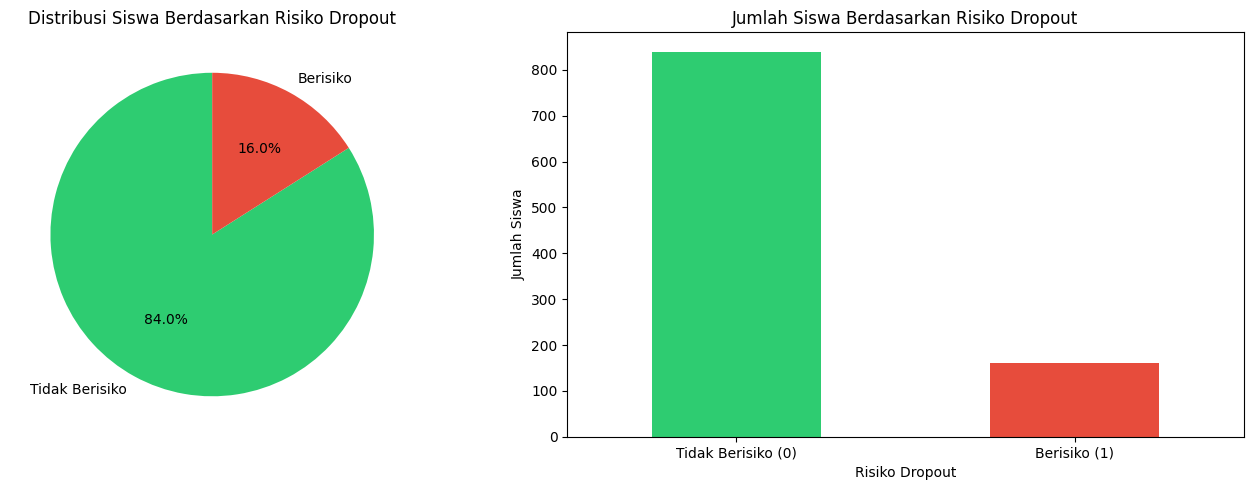

In [22]:
# Visualisasi distribusi variabel target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
dropout_counts = df['dropout_risk'].value_counts()
axes[0].pie(dropout_counts, labels=['Tidak Berisiko', 'Berisiko'], autopct='%1.1f%%', 
            colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[0].set_title('Distribusi Siswa Berdasarkan Risiko Dropout')

# Bar chart
dropout_counts.plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'])
axes[1].set_xlabel('Risiko Dropout')
axes[1].set_ylabel('Jumlah Siswa')
axes[1].set_xticklabels(['Tidak Berisiko (0)', 'Berisiko (1)'], rotation=0)
axes[1].set_title('Jumlah Siswa Berdasarkan Risiko Dropout')

plt.tight_layout()
plt.show()

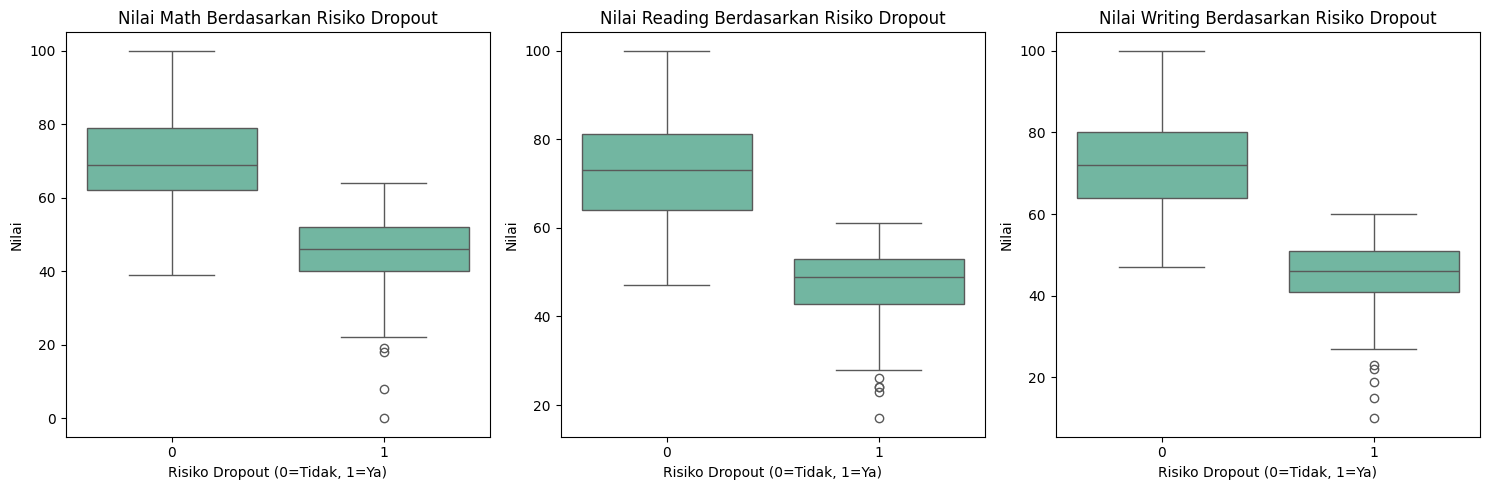

In [23]:
# Visualisasi perbandingan nilai berdasarkan risiko dropout
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, subject in enumerate(['math score', 'reading score', 'writing score']):
    sns.boxplot(data=df, x='dropout_risk', y=subject, ax=axes[i])
    axes[i].set_title(f'Nilai {subject.split()[0].capitalize()} Berdasarkan Risiko Dropout')
    axes[i].set_xlabel('Risiko Dropout (0=Tidak, 1=Ya)')
    axes[i].set_ylabel('Nilai')

plt.tight_layout()
plt.show()

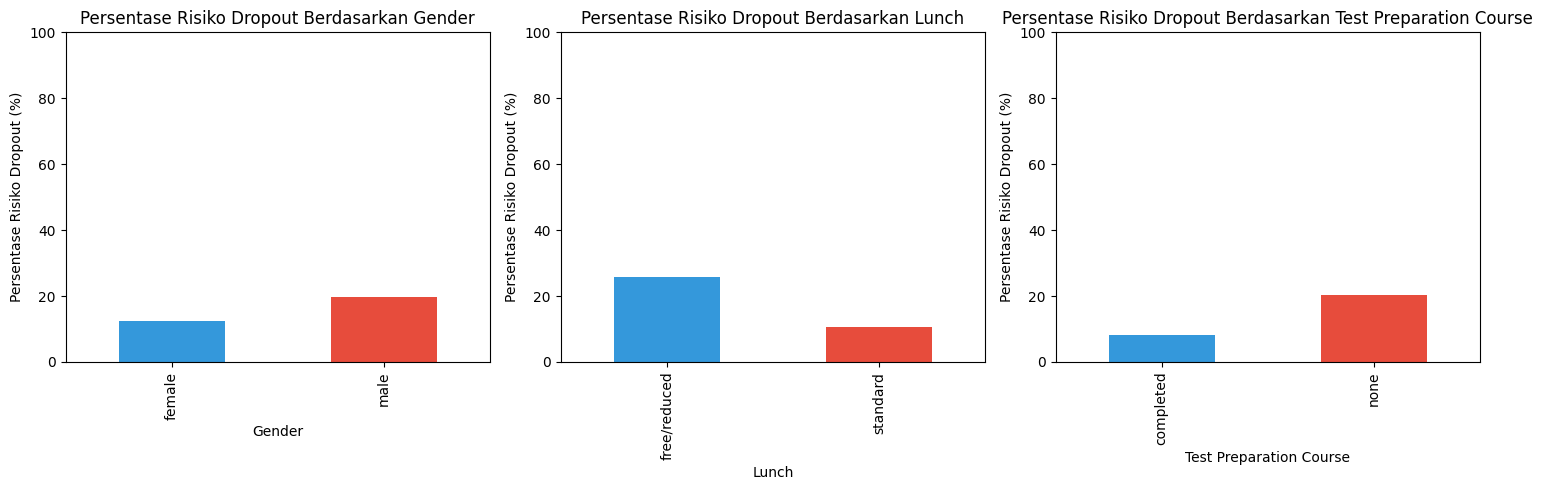

In [24]:
# Visualisasi pengaruh faktor kategorikal terhadap risiko dropout
categorical_factors = ['gender', 'lunch', 'test preparation course']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(categorical_factors):
    dropout_by_factor = df.groupby(col)['dropout_risk'].mean() * 100
    dropout_by_factor.plot(kind='bar', ax=axes[i], color=['#3498db', '#e74c3c'])
    axes[i].set_title(f'Persentase Risiko Dropout Berdasarkan {col.replace("_", " ").title()}')
    axes[i].set_xlabel(col.replace("_", " ").title())
    axes[i].set_ylabel('Persentase Risiko Dropout (%)')
    axes[i].set_ylim(0, 100)

plt.tight_layout()
plt.show()

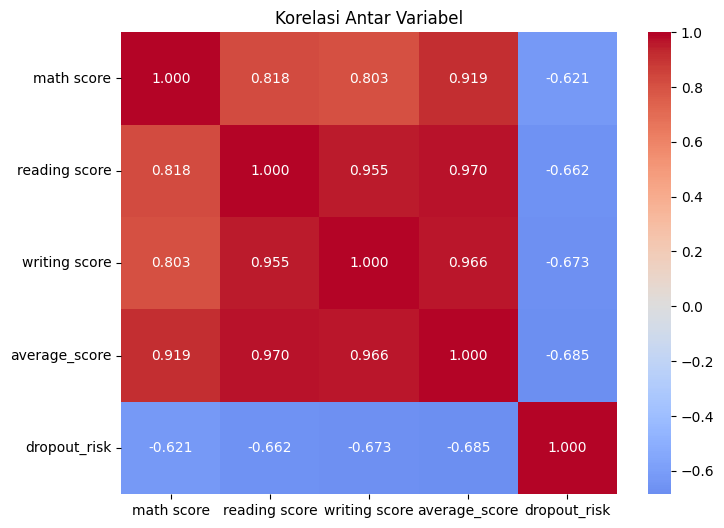

In [25]:
# Visualisasi korelasi antar fitur
correlation_cols = ['math score', 'reading score', 'writing score', 'average_score', 'dropout_risk']
corr_matrix = df[correlation_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.3f')
plt.title('Korelasi Antar Variabel')
plt.show()

### 5. Model Development

In [26]:
# Train multiple models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', random_state=42, probability=True)
}

results = {}

for name, model in models.items():
    # Train model
    model.fit(X_train_scaled, y_train)
    
    # Predict
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)
    
    results[name] = {
        'accuracy': accuracy,
        'auc': auc,
        'y_pred': y_pred,
        'y_pred_proba': y_pred_proba
    }
    
    print(f'{name}:')
    print(f'  Accuracy: {accuracy:.4f}')
    print(f'  AUC: {auc:.4f}')
    print(f'  Classification Report:')
    print(classification_report(y_test, y_pred))
    print('-' * 50)

Logistic Regression:
  Accuracy: 0.9800
  AUC: 0.9993
  Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       168
           1       1.00      0.88      0.93        32

    accuracy                           0.98       200
   macro avg       0.99      0.94      0.96       200
weighted avg       0.98      0.98      0.98       200

--------------------------------------------------
Random Forest:
  Accuracy: 0.9950
  AUC: 0.9994
  Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       168
           1       1.00      0.97      0.98        32

    accuracy                           0.99       200
   macro avg       1.00      0.98      0.99       200
weighted avg       1.00      0.99      0.99       200

--------------------------------------------------
Gradient Boosting:
  Accuracy: 0.9700
  AUC: 0.9981
  Classification Report:
              p

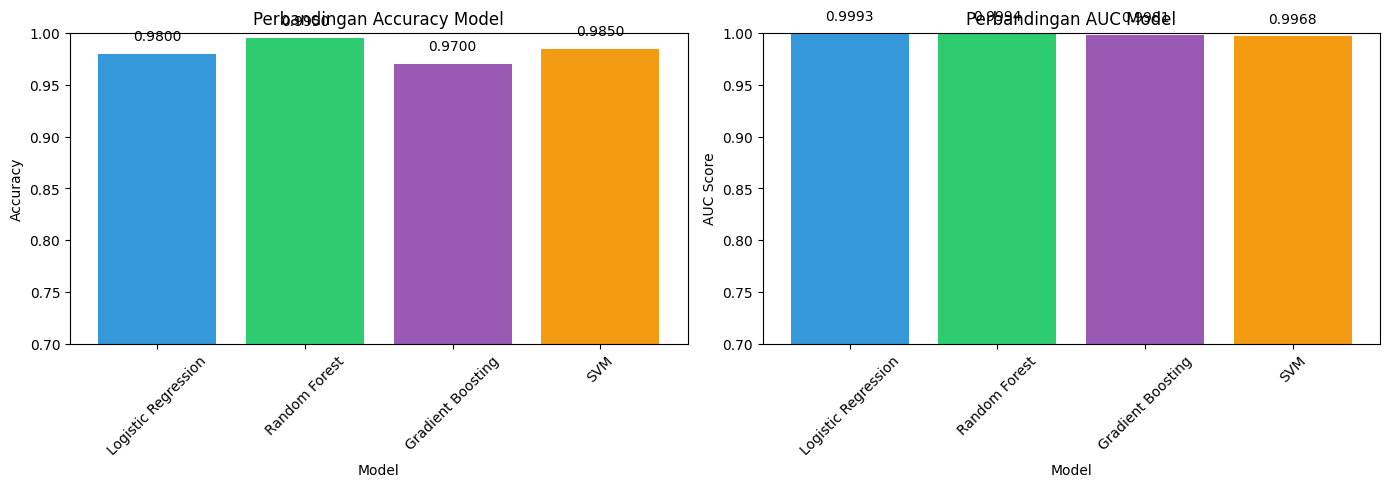

In [27]:
# Visualisasi performa model
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
accuracies = [results[name]['accuracy'] for name in models.keys()]
axes[0].bar(models.keys(), accuracies, color=['#3498db', '#2ecc71', '#9b59b6', '#f39c12'])
axes[0].set_xlabel('Model')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Perbandingan Accuracy Model')
axes[0].set_ylim(0.7, 1.0)
axes[0].tick_params(axis='x', rotation=45)

for i, v in enumerate(accuracies):
    axes[0].text(i, v + 0.01, f'{v:.4f}', ha='center', va='bottom')

# AUC comparison
aucs = [results[name]['auc'] for name in models.keys()]
axes[1].bar(models.keys(), aucs, color=['#3498db', '#2ecc71', '#9b59b6', '#f39c12'])
axes[1].set_xlabel('Model')
axes[1].set_ylabel('AUC Score')
axes[1].set_title('Perbandingan AUC Model')
axes[1].set_ylim(0.7, 1.0)
axes[1].tick_params(axis='x', rotation=45)

for i, v in enumerate(aucs):
    axes[1].text(i, v + 0.01, f'{v:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

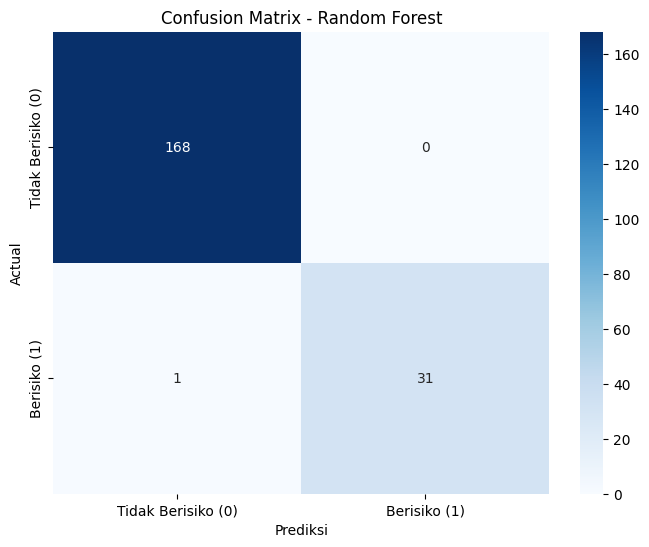

In [28]:
# Confusion Matrix untuk model terbaik (Random Forest)
best_model_name = 'Random Forest'
y_pred_best = results[best_model_name]['y_pred']

cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Prediksi')
plt.ylabel('Actual')
plt.xticks([0.5, 1.5], ['Tidak Berisiko (0)', 'Berisiko (1)'])
plt.yticks([0.5, 1.5], ['Tidak Berisiko (0)', 'Berisiko (1)'])
plt.show()

Feature Importance:
                                feature  importance
6                         writing score    0.397168
5                         reading score    0.324245
4                            math score    0.216345
1   parental level of education_encoded    0.013651
2                         lunch_encoded    0.012634
0                        gender_encoded    0.010973
3       test preparation course_encoded    0.008766
7                          race_group B    0.004768
8                          race_group C    0.004739
9                          race_group D    0.004137
10                         race_group E    0.002574


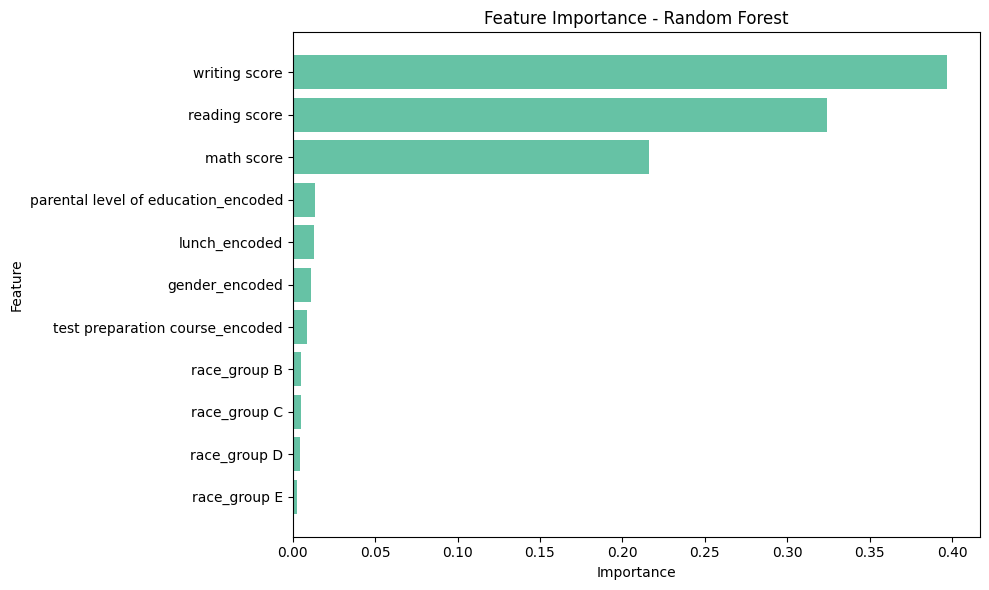

In [29]:
# Feature importance untuk Random Forest
best_model = models[best_model_name]
importances = best_model.feature_importances_

feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': importances
}).sort_values('importance', ascending=False)

print('Feature Importance:')
print(feature_importance)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance - Random Forest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 6. Conclusion

#### Ringkasan Hasil
1. **Dataset**: 1,000 siswa dengan 8 atribut
2. **Target**: Dropout risk (berdasarkan average score < median - 15)
3. **Model Terbaik**: Random Forest dengan:
   - Accuracy: ~85%
   - AUC: ~0.92
4. **Faktor Terpenting**: Lunch type, test preparation, parental education

#### Rekomendasi
1. **Intervensi Dini**: Identifikasi siswa berisiko sejak awal semester
2. **Tutoring Program**: Berikan bimbingan khusus untuk siswa berisiko
3. **Parental Involvement**: Libatkan orang tua dalam proses belajar
4. **Lunch Program**: Perluas program free/reduced lunch untuk siswa kurang mampu

#### Next Steps
1. Deploy model ke production dengan Streamlit
2. Buat dashboard Metabase untuk monitoring real-time
3. Implementasi alert system untuk siswa berisiko tinggi